In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds_ctrl = scarf.DataStore(
    f"{ctrl_path}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)
ds_stim = scarf.DataStore(
    f"{stim_path}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

In [2]:
ds_ctrl.cells.insert(
    "reference_batch",
    np.repeat("control", ds_ctrl.cells.N),
    overwrite=True,
)

In [3]:
run = ds_ctrl.pipeline.run(
    label="harmony_reference",
    filtering=False,
    cell_cycle=False,
    hvg_count=2000,
    pca_dims=25,
    harmony_batch_columns=["reference_batch"],
    neighbors_k=17,
    leiden=False,
    paris=False,
    doublets=False,
    markers=False,
    snapshot_columns=["cluster_labels"],
)
reference_layout = run["umap"]
reference_ref = ds_ctrl.build_mapping_reference(run["neighbors"])
reference_ref

ArtifactRef(assay='RNA', kind='mapping_reference', artifact_id='86c64928c37e...')

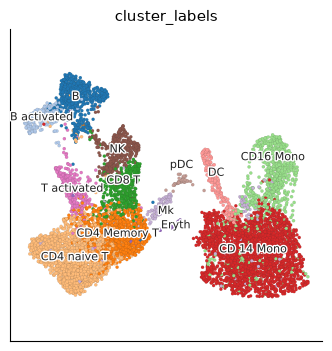

In [4]:
ds_ctrl.plots.embedding(
    run=run,
    layout="umap",
    color_by="cluster_labels",
)

In [5]:
reference_store = scarf.DataStore(
    f"{ctrl_path}/data.zarr",
    zarr_mode="r",
    nthreads=4,
)
reference = reference_store.get_mapping_reference(reference_ref)
pd.Series(
    {
        "method": reference.method,
        "assay": reference.assay_name,
        "selected_cells": reference.selected_cell_count,
        "n_features": reference.model.n_features,
        "n_dims": reference.model.n_dims,
        "has_symphony_state": reference.symphony_state is not None,
    },
    name="reloaded_mapping_reference",
)

method                symphony
assay                      RNA
selected_cells            8486
n_features                2000
n_dims                      25
has_symphony_state        True
Name: reloaded_mapping_reference, dtype: object

In [6]:
query_batches = pd.DataFrame(
    {
        "reference_batch": np.repeat(
            "stimulated",
            len(ds_stim.cells.fetch("ids", key="I")),
        )
    }
)
query_cell_selection = ds_stim.snapshot_cell_selection("I")
mapping_ref = ds_stim.run_mapping(
    reference,
    query_cell_selection,
    query_assay="RNA",
    save_k=5,
    query_batches=query_batches,
)
mapping_ref

ArtifactRef(assay='RNA', kind='projection', artifact_id='cb0f1c1d2791...')

In [7]:
mapped = ds_stim.get_mapping_result(
    mapping_ref,
    reference=reference,
    load_arrays=True,
)
mapped.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1,
 'algorithmVariant': 'symphony',
 'zeroNormCellCount': 0,
 'queryScaledDispersion': 1.3597154177596102}

In [8]:
transferred = ds_stim.get_target_classes(
    mapping_ref,
    reference_class_group="cluster_labels",
    reference=reference,
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "atlas_labels",
    transferred.to_numpy(),
    overwrite=True,
)
accepted = transferred.notna() & transferred.ne("NA")
accepted.value_counts().rename(
    index={True: "accepted", False: "abstained"}
).rename("query cells")

accepted     8335
abstained    1776
Name: query cells, dtype: int64

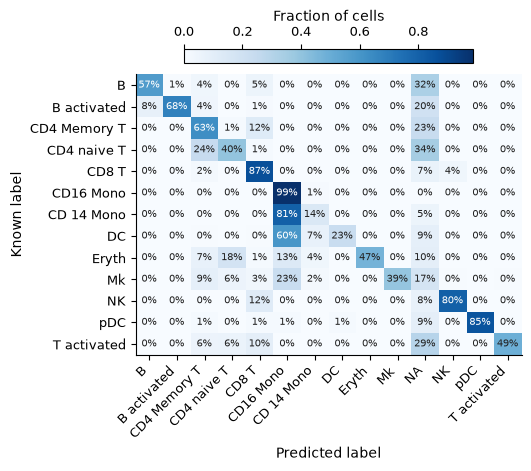

In [9]:
query_labels = np.asarray(ds_stim.cells.fetch("cluster_labels")).astype(str)
ds_stim.plots.mapping_confusion(
    mapping_ref,
    reference=reference,
    reference_class_group="cluster_labels",
    known_labels=query_labels,
    normalize="true",
    threshold_fraction=0.6,
)

In [10]:
focus_labels = ("CD4 Memory T", "CD 14 Mono", "NK")
focus_groups = np.array(
    [label if label in focus_labels else "other" for label in query_labels],
    dtype=object,
)
ref_classes = np.asarray(
    reference.fetch_cell_column("cluster_labels"),
    dtype=object,
)
score_mass: dict[str, pd.Series] = {}
for group, values in ds_stim.get_mapping_score(
    mapping_ref,
    target_groups=focus_groups,
    reference=reference,
    log_transform=False,
):
    if group == "other":
        continue
    score_mass[str(group)] = (
        pd.Series(np.asarray(values, dtype=np.float64), index=ref_classes)
        .groupby(level=0, sort=False)
        .sum()
    )
score_mass_table = pd.DataFrame(
    {label: score_mass[label] for label in focus_labels if label in score_mass}
).fillna(0.0)
score_mass_table.loc[
    score_mass_table.max(axis=1).sort_values(ascending=False).index
].round(3)

,CD4 Memory T,CD 14 Mono,NK
CD16 Mono,0.000,284.073,0.000
NK,0.093,0.000,253.839
CD4 Memory T,212.273,0.183,0.936
CD 14 Mono,0.000,63.942,0.424
CD8 T,62.385,0.647,48.662
CD4 naive T,37.687,0.358,1.723
T activated,0.883,0.000,0.130
Mk,0.168,0.028,0.392
B,0.000,0.000,0.136
B activated,0.047,0.000,0.000


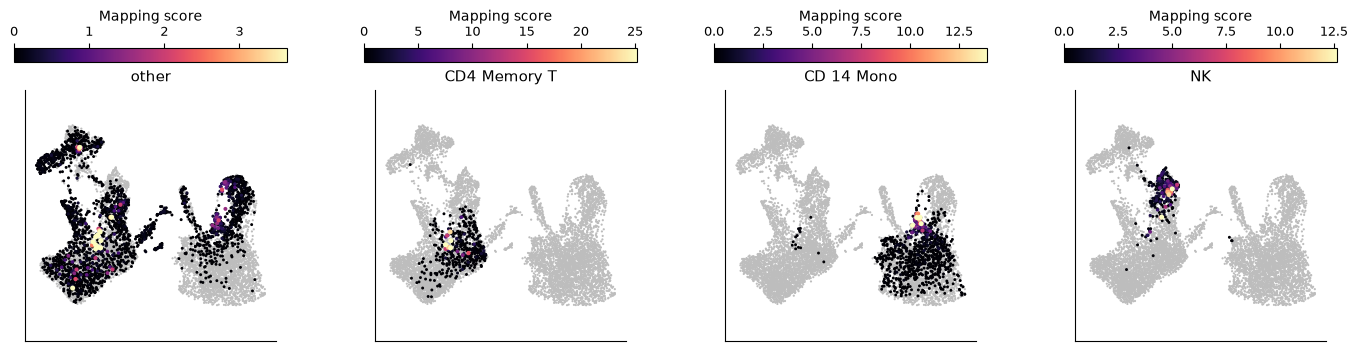

In [11]:
ds_stim.plots.mapping_score(
    mapping_ref,
    reference=reference,
    layout=reference_layout,
    target_groups=focus_groups,
    size_by_score=True,
    log_transform=False,
    figsize=(14, 3.4),
)